# Indian Mutual Fund Industry - Exploratory Data Analysis (2022-2026)**Author:** Maneesh Reddy  **Date:** June 2026  **Dataset:** Bluestock Mutual Fund Datasets (10 CSV files, ~87K records)---## Table of Contents1. [Setup & Data Loading](#1-setup--data-loading)2. [NAV Trend Analysis](#2-nav-trend-analysis)3. [AUM Growth by Fund House](#3-aum-growth-by-fund-house)4. [SIP Inflow Time-Series](#4-sip-inflow-time-series)5. [Category Inflow Heatmap](#5-category-inflow-heatmap)6. [Investor Demographics](#6-investor-demographics)7. [Geographic Distribution](#7-geographic-distribution)8. [Folio Count Growth](#8-folio-count-growth)9. [NAV Return Correlation Matrix](#9-nav-return-correlation-matrix)10. [Sector Allocation Donut](#10-sector-allocation-donut)11. [10 Key EDA Findings](#11-10-key-eda-findings)12. [Export Charts](#12-export-charts)

## 1. Setup & Data Loading

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['figure.dpi'] = 100

FUND_HOUSE_COLORS = {
    'SBI Mutual Fund': '#1a5276',
    'HDFC Mutual Fund': '#2e86c1',
    'ICICI Prudential MF': '#2874a6',
    'Nippon India MF': '#7d3c98',
    'Kotak Mahindra MF': '#c0392b',
    'Axis Mutual Fund': '#d35400',
    'Aditya Birla Sun Life MF': '#27ae60',
    'UTI Mutual Fund': '#f39c12',
    'Mirae Asset MF': '#8e44ad',
    'DSP Mutual Fund': '#16a085'
}

os.makedirs('../reports/figures', exist_ok=True)
DATA_DIR = '../data_1/Bluestock_MF_Datasets/'
print('Setup complete')


Setup complete


In [2]:
fund_master = pd.read_csv(DATA_DIR + '01_fund_master.csv', parse_dates=['launch_date'])
nav_history = pd.read_csv(DATA_DIR + '02_nav_history.csv', parse_dates=['date'])
aum_data = pd.read_csv(DATA_DIR + '03_aum_by_fund_house.csv', parse_dates=['date'])
sip_inflows = pd.read_csv(DATA_DIR + '04_monthly_sip_inflows.csv', parse_dates=['month'])
category_inflows = pd.read_csv(DATA_DIR + '05_category_inflows.csv', parse_dates=['month'])
folio_count = pd.read_csv(DATA_DIR + '06_industry_folio_count.csv', parse_dates=['month'])
scheme_perf = pd.read_csv(DATA_DIR + '07_scheme_performance.csv')
transactions = pd.read_csv(DATA_DIR + '08_investor_transactions.csv', parse_dates=['transaction_date'])
portfolio = pd.read_csv(DATA_DIR + '09_portfolio_holdings.csv', parse_dates=['portfolio_date'])
benchmark = pd.read_csv(DATA_DIR + '10_benchmark_indices.csv', parse_dates=['date'])
print('All datasets loaded')


All datasets loaded


In [3]:
nav_merged = nav_history.merge(
    fund_master[['amfi_code', 'scheme_name', 'fund_house', 'category', 'sub_category']],
    on='amfi_code', how='left'
)
print('NAV merged shape:', nav_merged.shape)


NAV merged shape: (46000, 7)


---## 2. NAV Trend Analysis - All 40 Schemes (2022-2026)**Chart 1:** Plotly line chart of daily NAV for 10 representative schemes, highlighting the 2023 bull run and 2024 market corrections.

In [4]:
nav_pivot = nav_merged.pivot_table(index='date', columns='scheme_name', values='nav')
nav_normalised = (nav_pivot / nav_pivot.iloc[0]) * 100
selected_funds = [
    'SBI Bluechip Fund - Regular Plan - Growth',
    'SBI Small Cap Fund - Regular Plan - Growth',
    'HDFC Top 100 Fund - Regular Plan - Growth',
    'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
    'ICICI Pru Bluechip Fund - Regular - Growth',
    'ICICI Pru Midcap Fund - Regular - Growth',
    'Nippon India Large Cap Fund - Regular - Growth',
    'Nippon India Small Cap Fund - Regular - Growth',
    'Kotak Bluechip Fund - Regular - Growth',
    'Axis Midcap Fund - Regular - Growth'
]
nav_selected = nav_normalised[selected_funds]
print('Selected funds NAV shape:', nav_selected.shape)


Selected funds NAV shape: (1150, 10)


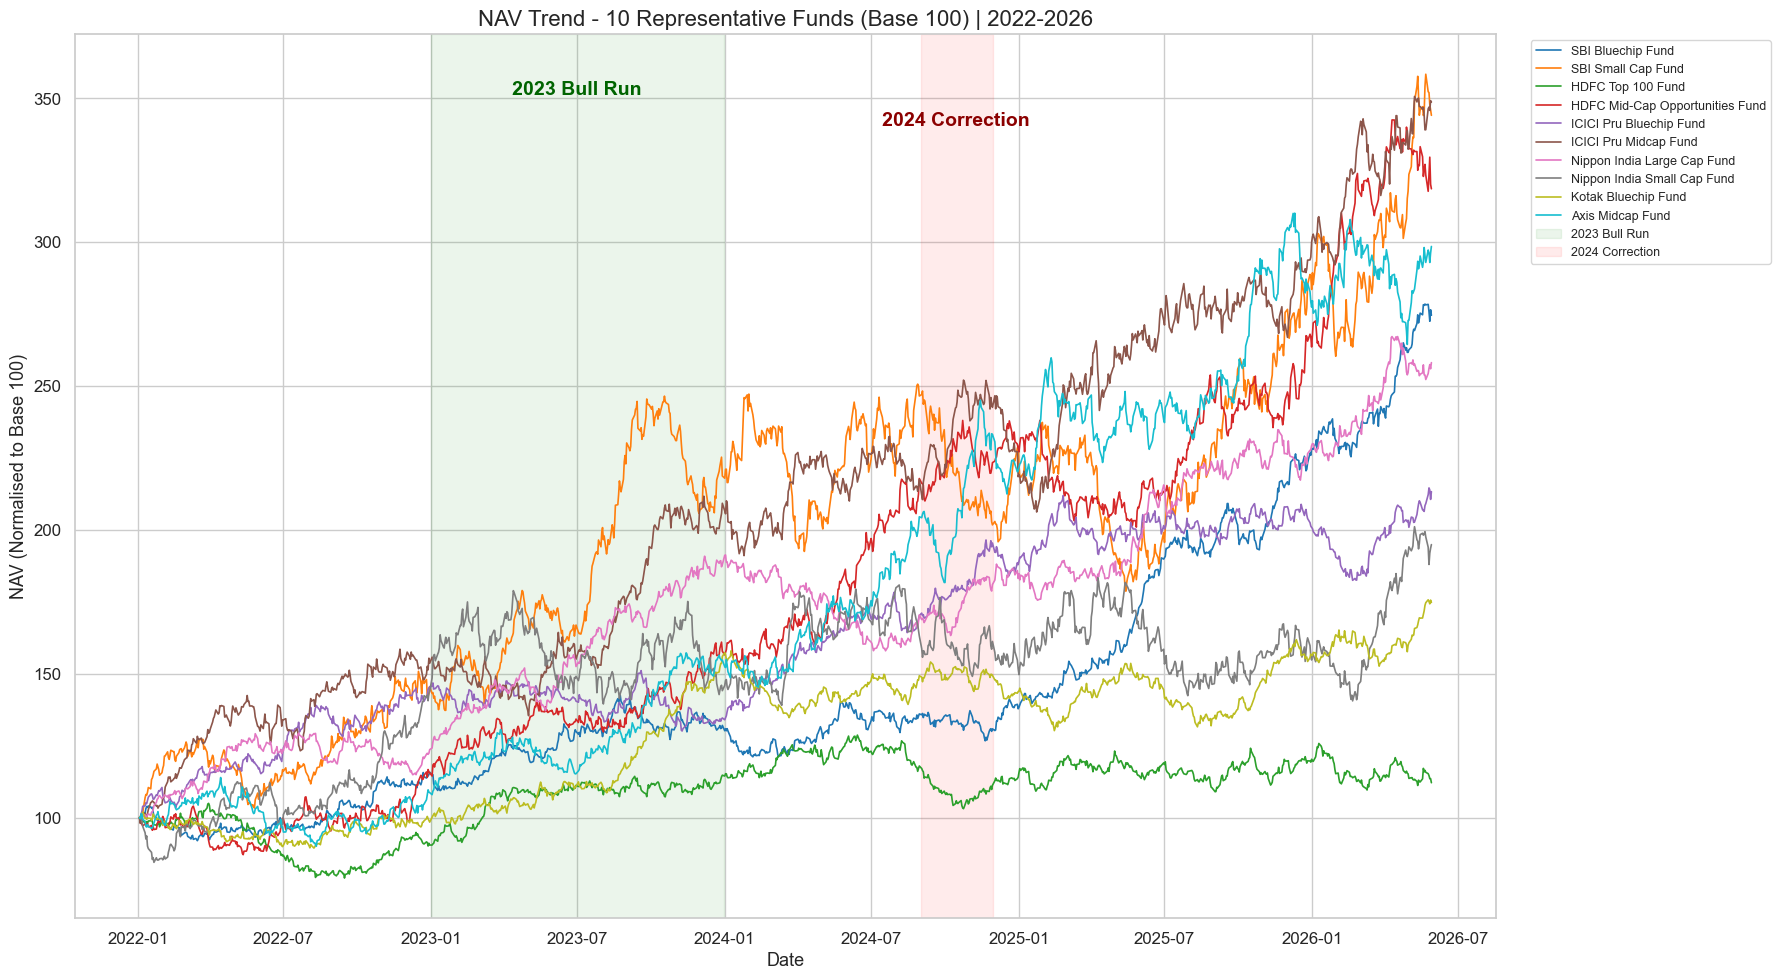

Saved 01_nav_trend_all_schemes.png


In [5]:
# Chart 1: NAV Trend using Matplotlib (static PNG)
fig, ax = plt.subplots(figsize=(18, 10))
colors = plt.cm.tab10(np.linspace(0, 1, len(selected_funds)))
for i, fund in enumerate(selected_funds):
    short = fund.replace(' - Regular Plan - Growth', '').replace(' - Regular - Growth', '')
    ax.plot(nav_selected.index, nav_selected[fund], label=short, color=colors[i], linewidth=1.2)

# Highlight 2023 Bull Run
ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31'), alpha=0.08, color='green', label='2023 Bull Run')
ax.axvspan(pd.Timestamp('2024-09-01'), pd.Timestamp('2024-11-30'), alpha=0.08, color='red', label='2024 Correction')

ax.annotate('2023 Bull Run', xy=(pd.Timestamp('2023-07-01'), nav_selected.max().max() * 0.98),
            fontsize=14, color='darkgreen', fontweight='bold', ha='center')
ax.annotate('2024 Correction', xy=(pd.Timestamp('2024-10-15'), nav_selected.max().max() * 0.95),
            fontsize=14, color='darkred', fontweight='bold', ha='center')

ax.set_title('NAV Trend - 10 Representative Funds (Base 100) | 2022-2026', fontsize=16)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('NAV (Normalised to Base 100)', fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/01_nav_trend_all_schemes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved 01_nav_trend_all_schemes.png')


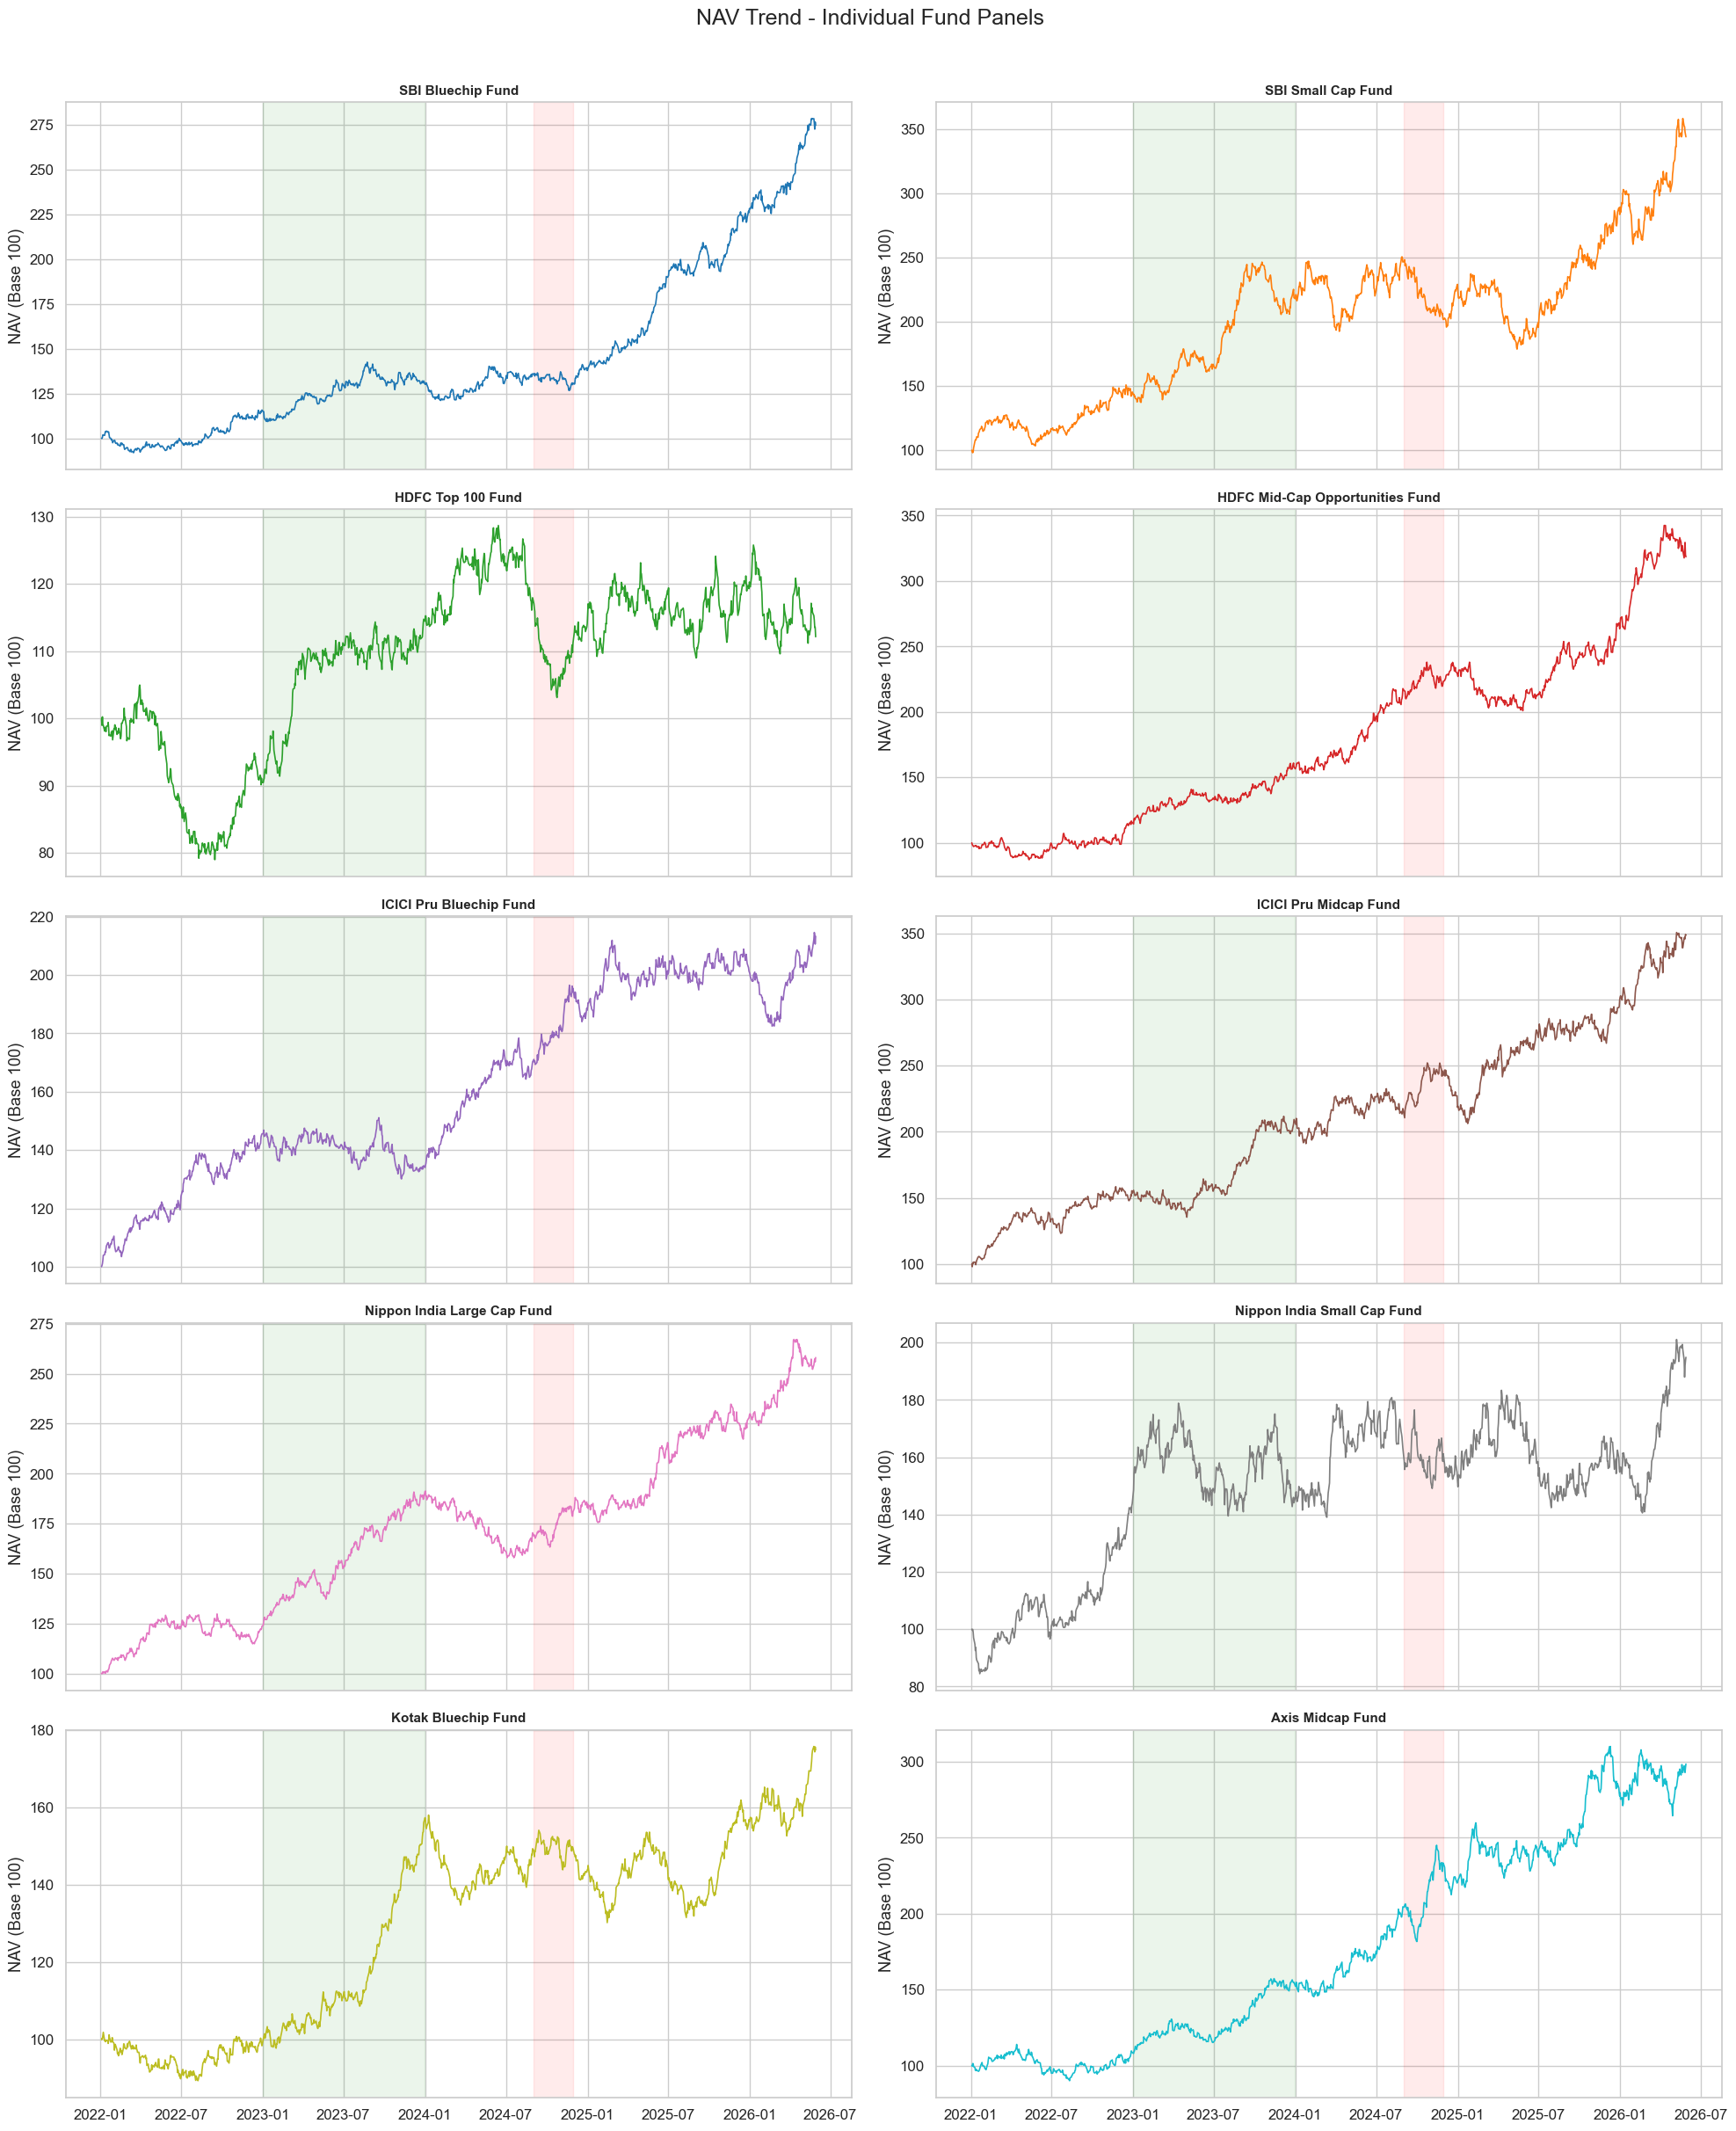

Saved 01b_nav_trend_faceted.png


In [6]:
# Chart 1b: Faceted NAV trend
fig, axes = plt.subplots(5, 2, figsize=(20, 24), sharex=True)
axes = axes.flatten()
for i, fund in enumerate(selected_funds):
    short = fund.replace(' - Regular Plan - Growth', '').replace(' - Regular - Growth', '')
    axes[i].plot(nav_selected.index, nav_selected[fund], color=colors[i], linewidth=1.2)
    axes[i].axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31'), alpha=0.08, color='green')
    axes[i].axvspan(pd.Timestamp('2024-09-01'), pd.Timestamp('2024-11-30'), alpha=0.08, color='red')
    axes[i].set_title(short, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('NAV (Base 100)')
plt.suptitle('NAV Trend - Individual Fund Panels', fontsize=18, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/01b_nav_trend_faceted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved 01b_nav_trend_faceted.png')


---## 3. AUM Growth by Fund House**Chart 2:** Grouped bar chart by fund house for each year (2022-2025), highlighting SBI dominance at Rs.12.5L Cr.

In [7]:
aum_data['year'] = aum_data['date'].dt.year
aum_yearly = aum_data[aum_data['date'].dt.month.isin([3, 9, 12])].copy()
aum_latest = aum_yearly.sort_values('date').groupby(['year', 'fund_house']).last().reset_index()
aum_pivot = aum_latest.pivot_table(index='year', columns='fund_house', values='aum_lakh_crore')
aum_pivot = aum_pivot.reindex(columns=FUND_HOUSE_COLORS.keys())
print(aum_pivot)


fund_house  SBI Mutual Fund  HDFC Mutual Fund  ICICI Prudential MF  \
year                                                                 
2022                   6.30              4.45                 4.88   
2023                   8.45              5.35                 5.90   
2024                  11.14              7.87                 8.74   
2025                  12.50              9.30                10.74   

fund_house  Nippon India MF  Kotak Mahindra MF  Axis Mutual Fund  \
year                                                               
2022                   2.78               2.72               2.4   
2023                   3.40               3.25               2.6   
2024                   5.70               4.89               3.0   
2025                   7.00               5.80               3.5   

fund_house  Aditya Birla Sun Life MF  UTI Mutual Fund  Mirae Asset MF  \
year                                                                    
2022                    

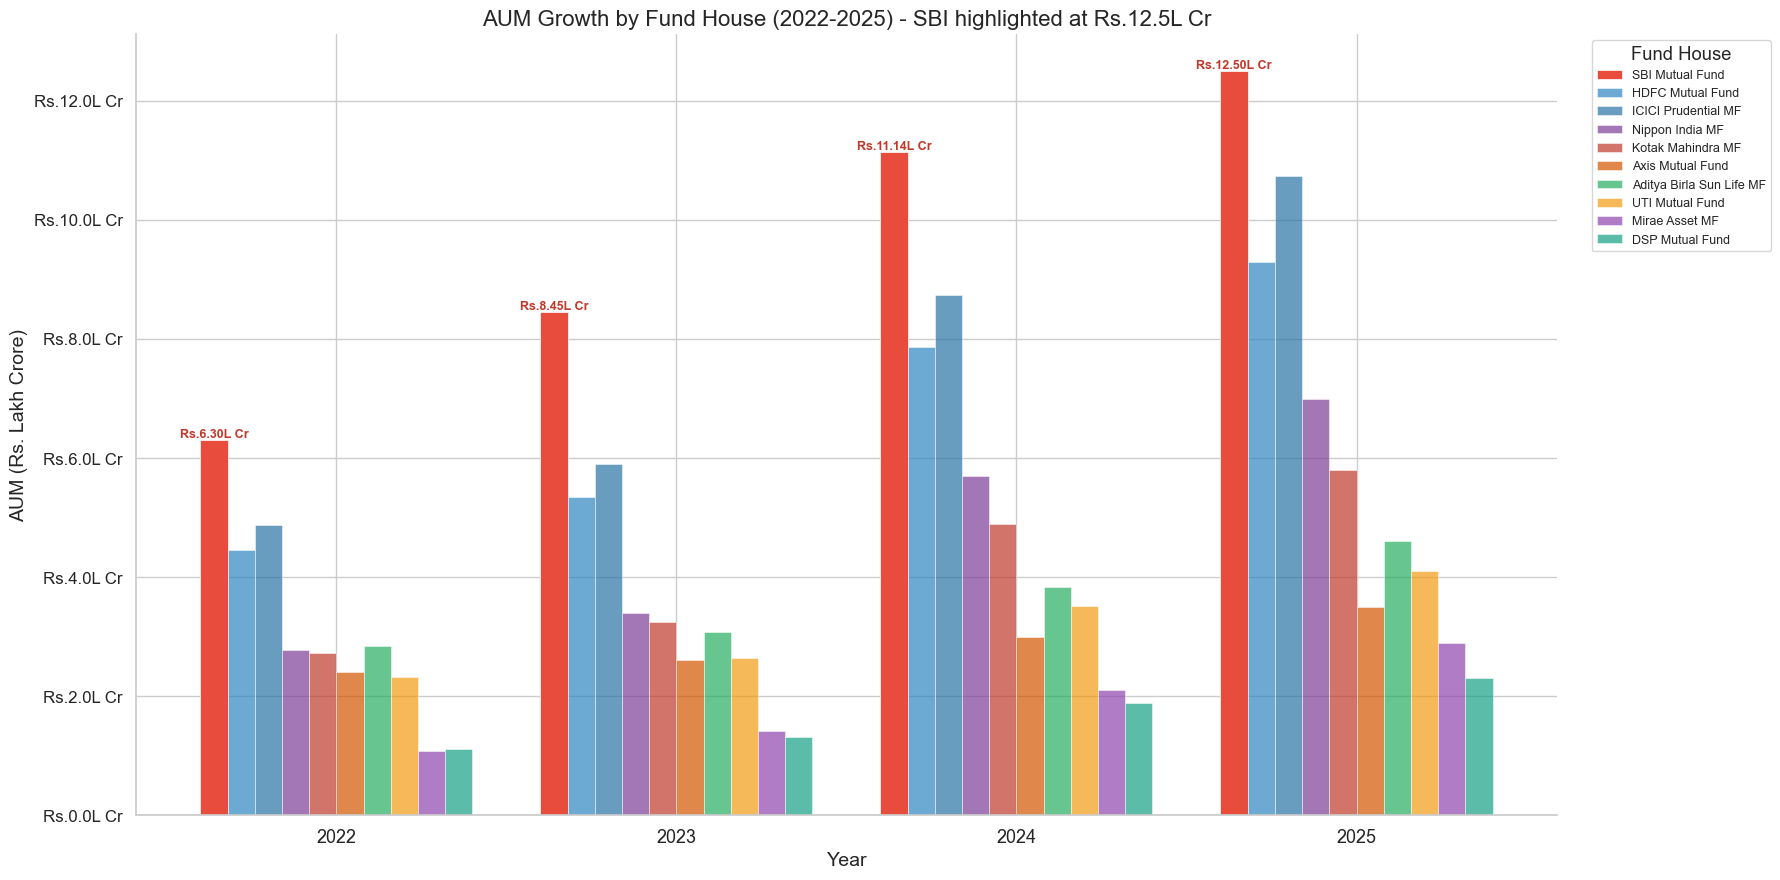

In [8]:
fig, ax = plt.subplots(figsize=(18, 9))
aum_melted = aum_latest.copy()
years = sorted(aum_melted['year'].unique())
fund_houses = list(FUND_HOUSE_COLORS.keys())
n_years = len(years)
n_funds = len(fund_houses)
bar_width = 0.8 / n_funds

for j, fh in enumerate(fund_houses):
    fh_data = aum_melted[aum_melted['fund_house'] == fh].set_index('year')['aum_lakh_crore']
    positions = np.arange(n_years) + j * bar_width
    color = '#e74c3c' if fh == 'SBI Mutual Fund' else FUND_HOUSE_COLORS.get(fh, '#95a5a6')
    alpha = 1.0 if fh == 'SBI Mutual Fund' else 0.7
    ax.bar(positions, [fh_data.get(y, 0) for y in years],
           width=bar_width, label=fh, color=color, alpha=alpha, edgecolor='white', linewidth=0.5)
    if fh == 'SBI Mutual Fund':
        for pos, yr in zip(positions, years):
            val = fh_data.get(yr, 0)
            ax.annotate(f'Rs.{val:.2f}L Cr', xy=(pos, val), ha='center', va='bottom',
                       fontweight='bold', fontsize=9, color='#c0392b')

ax.set_xticks(np.arange(n_years) + bar_width * (n_funds - 1) / 2)
ax.set_xticklabels([str(y) for y in years], fontsize=13)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('AUM (Rs. Lakh Crore)', fontsize=14)
ax.set_title('AUM Growth by Fund House (2022-2025) - SBI highlighted at Rs.12.5L Cr', fontsize=16)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, title='Fund House')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs.{x:.1f}L Cr'))
sns.despine()
plt.tight_layout()
plt.savefig('../reports/figures/02_aum_growth_by_fund_house.png', dpi=150, bbox_inches='tight')
plt.show()


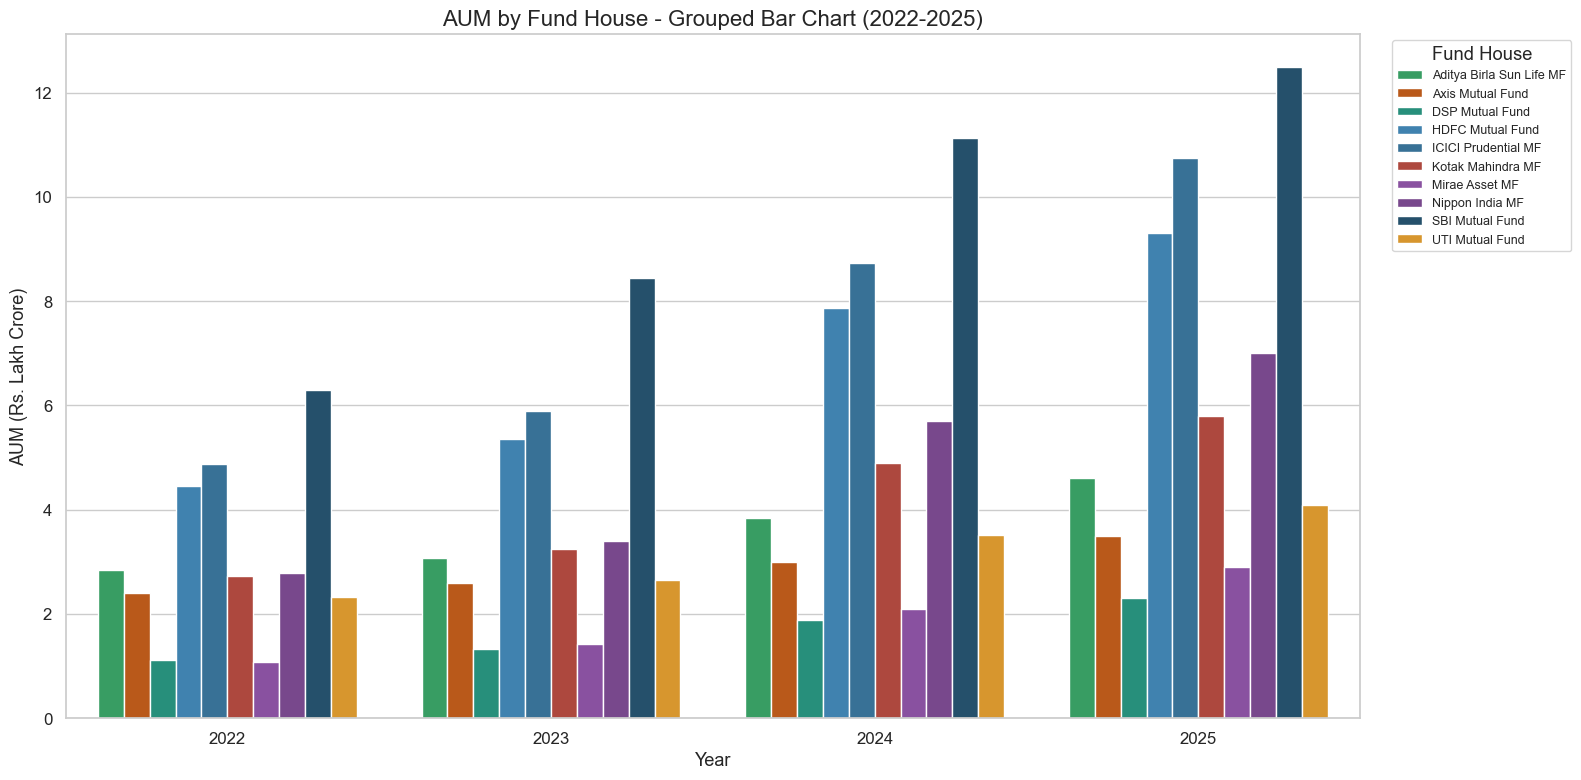

In [9]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.barplot(data=aum_latest, x='year', y='aum_lakh_crore', hue='fund_house',
            palette=FUND_HOUSE_COLORS, ax=ax, edgecolor='white')
ax.set_title('AUM by Fund House - Grouped Bar Chart (2022-2025)', fontsize=16)
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('AUM (Rs. Lakh Crore)', fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, title='Fund House')
plt.tight_layout()
plt.savefig('../reports/figures/02b_aum_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()


---## 4. SIP Inflow Time-Series**Chart 3:** Monthly SIP trend (Jan 2022 - Dec 2025), annotating the Rs.31,002 Cr all-time high (Dec 2025).

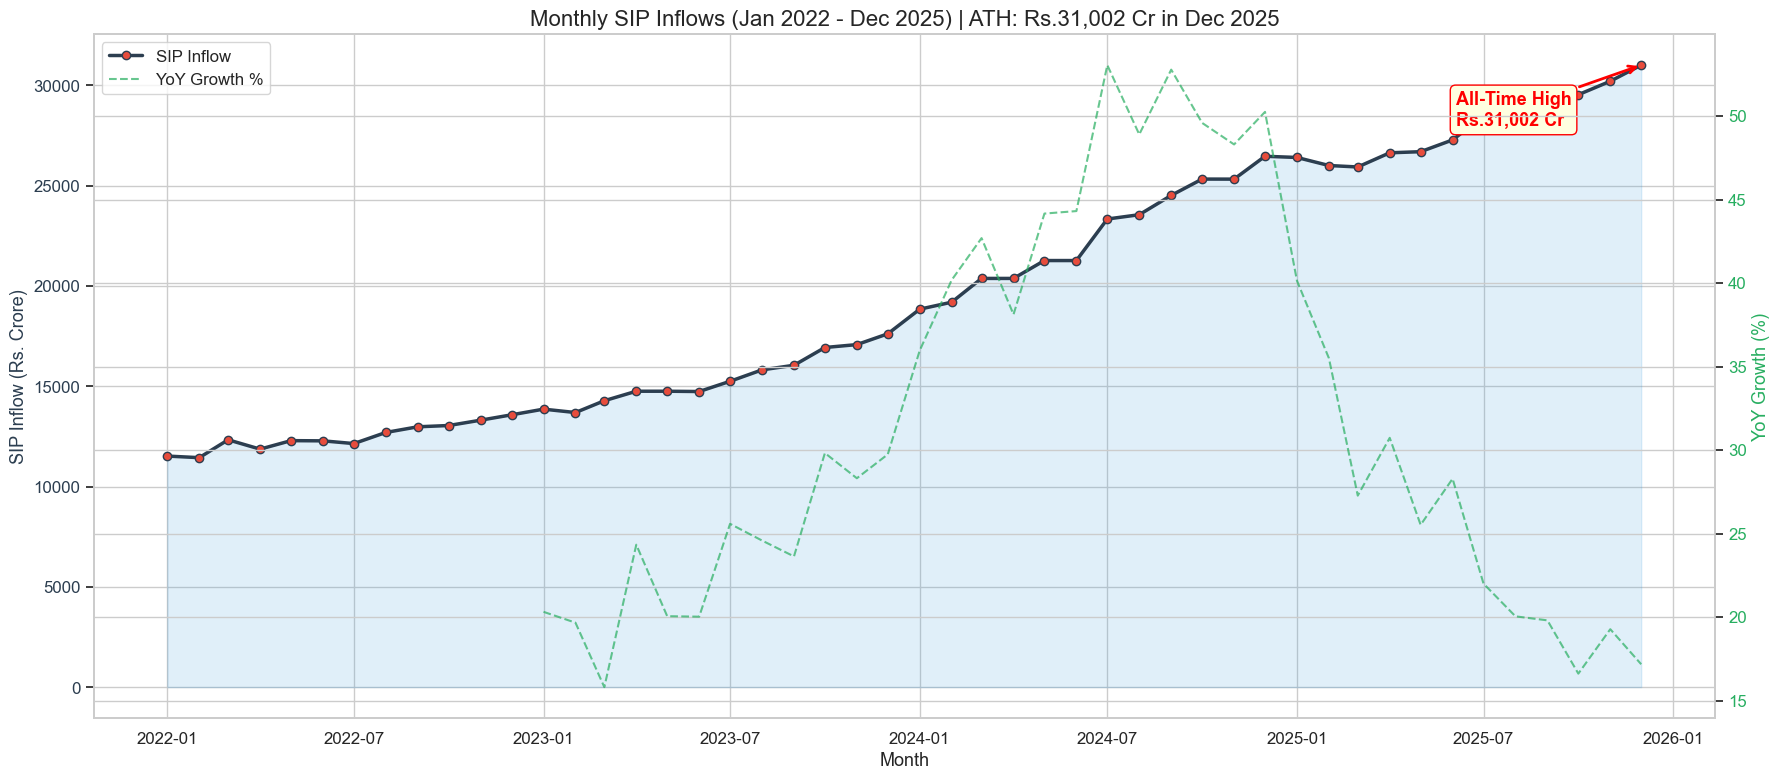

In [10]:
# Chart 3: SIP Inflow - Matplotlib with annotation
fig, ax1 = plt.subplots(figsize=(18, 8))

ax1.fill_between(sip_inflows['month'], sip_inflows['sip_inflow_crore'], alpha=0.15, color='#3498db')
ax1.plot(sip_inflows['month'], sip_inflows['sip_inflow_crore'], 'o-', color='#2c3e50',
         linewidth=2.5, markersize=6, markerfacecolor='#e74c3c', label='SIP Inflow')
ax1.set_xlabel('Month', fontsize=13)
ax1.set_ylabel('SIP Inflow (Rs. Crore)', fontsize=13, color='#2c3e50')
ax1.tick_params(axis='y', labelcolor='#2c3e50')

# YoY on secondary axis
ax2 = ax1.twinx()
ax2.plot(sip_inflows['month'], sip_inflows['yoy_growth_pct'], '--', color='#27ae60',
         linewidth=1.5, alpha=0.7, label='YoY Growth %')
ax2.set_ylabel('YoY Growth (%)', fontsize=13, color='#27ae60')
ax2.tick_params(axis='y', labelcolor='#27ae60')

# Annotate ATH
ath_row = sip_inflows.loc[sip_inflows['sip_inflow_crore'].idxmax()]
ax1.annotate(f'All-Time High\nRs.{ath_row["sip_inflow_crore"]:,.0f} Cr',
             xy=(ath_row['month'], ath_row['sip_inflow_crore']),
             xytext=(ath_row['month'] - pd.Timedelta(days=180), ath_row['sip_inflow_crore'] - 3000),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=13, color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='red'))

ax1.set_title('Monthly SIP Inflows (Jan 2022 - Dec 2025) | ATH: Rs.31,002 Cr in Dec 2025', fontsize=16)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('../reports/figures/03_sip_inflow_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


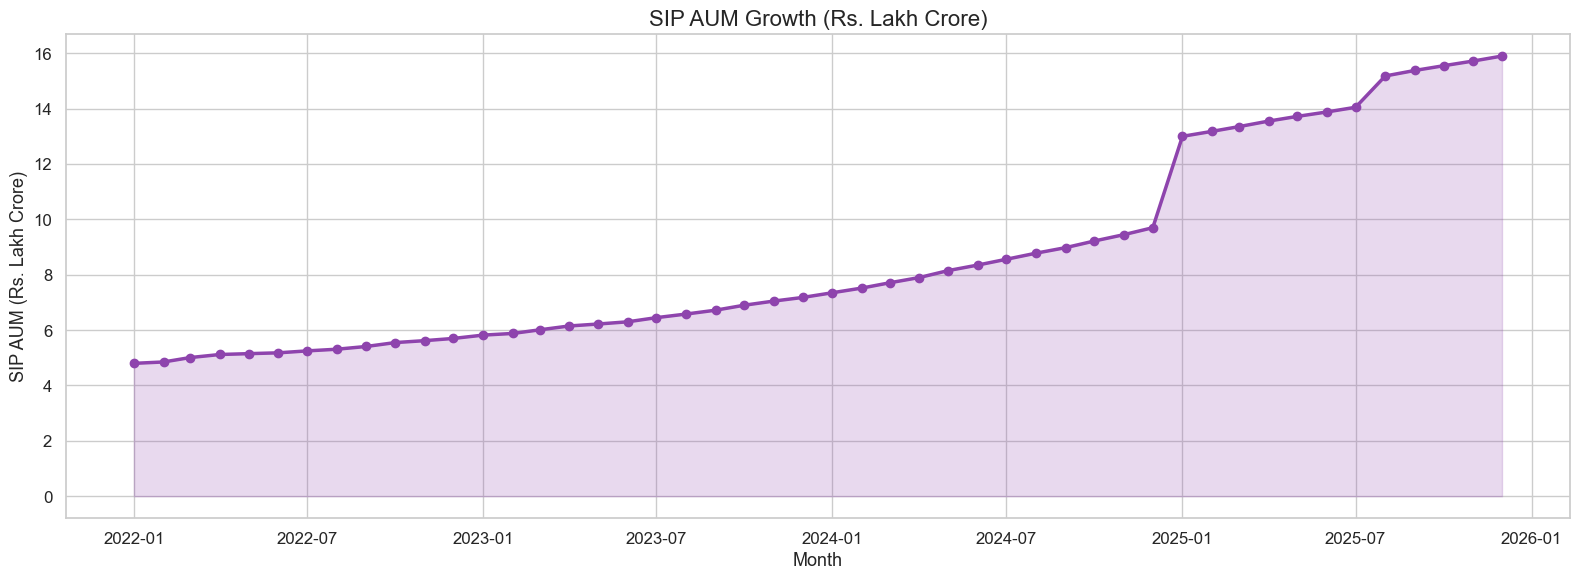

In [11]:
# Chart 3b: SIP AUM Growth
fig, ax = plt.subplots(figsize=(16, 6))
ax.fill_between(sip_inflows['month'], sip_inflows['sip_aum_lakh_crore'], alpha=0.2, color='#8e44ad')
ax.plot(sip_inflows['month'], sip_inflows['sip_aum_lakh_crore'], 'o-', color='#8e44ad',
         linewidth=2.5, markersize=6)
ax.set_title('SIP AUM Growth (Rs. Lakh Crore)', fontsize=16)
ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('SIP AUM (Rs. Lakh Crore)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/03b_sip_aum_growth.png', dpi=150, bbox_inches='tight')
plt.show()


---## 5. Category Inflow Heatmap**Chart 4:** Months on X-axis, fund categories on Y-axis, net inflow as colour intensity (Seaborn).

In [12]:
category_inflows['month_name'] = category_inflows['month'].dt.strftime('%b %Y')
category_inflows['month_sort'] = category_inflows['month']
cat_pivot = category_inflows.pivot_table(index='category', columns='month_name', values='net_inflow_crore')
month_order = category_inflows.sort_values('month_sort')['month_name'].unique()
cat_pivot = cat_pivot.reindex(columns=month_order)
print('Categories:', cat_pivot.index.tolist())


Categories: ['ELSS', 'Flexi Cap', 'Gilt', 'Hybrid', 'Large & Mid Cap', 'Large Cap', 'Liquid', 'Mid Cap', 'Sectoral/Thematic', 'Short Duration', 'Small Cap', 'Value/Contra']


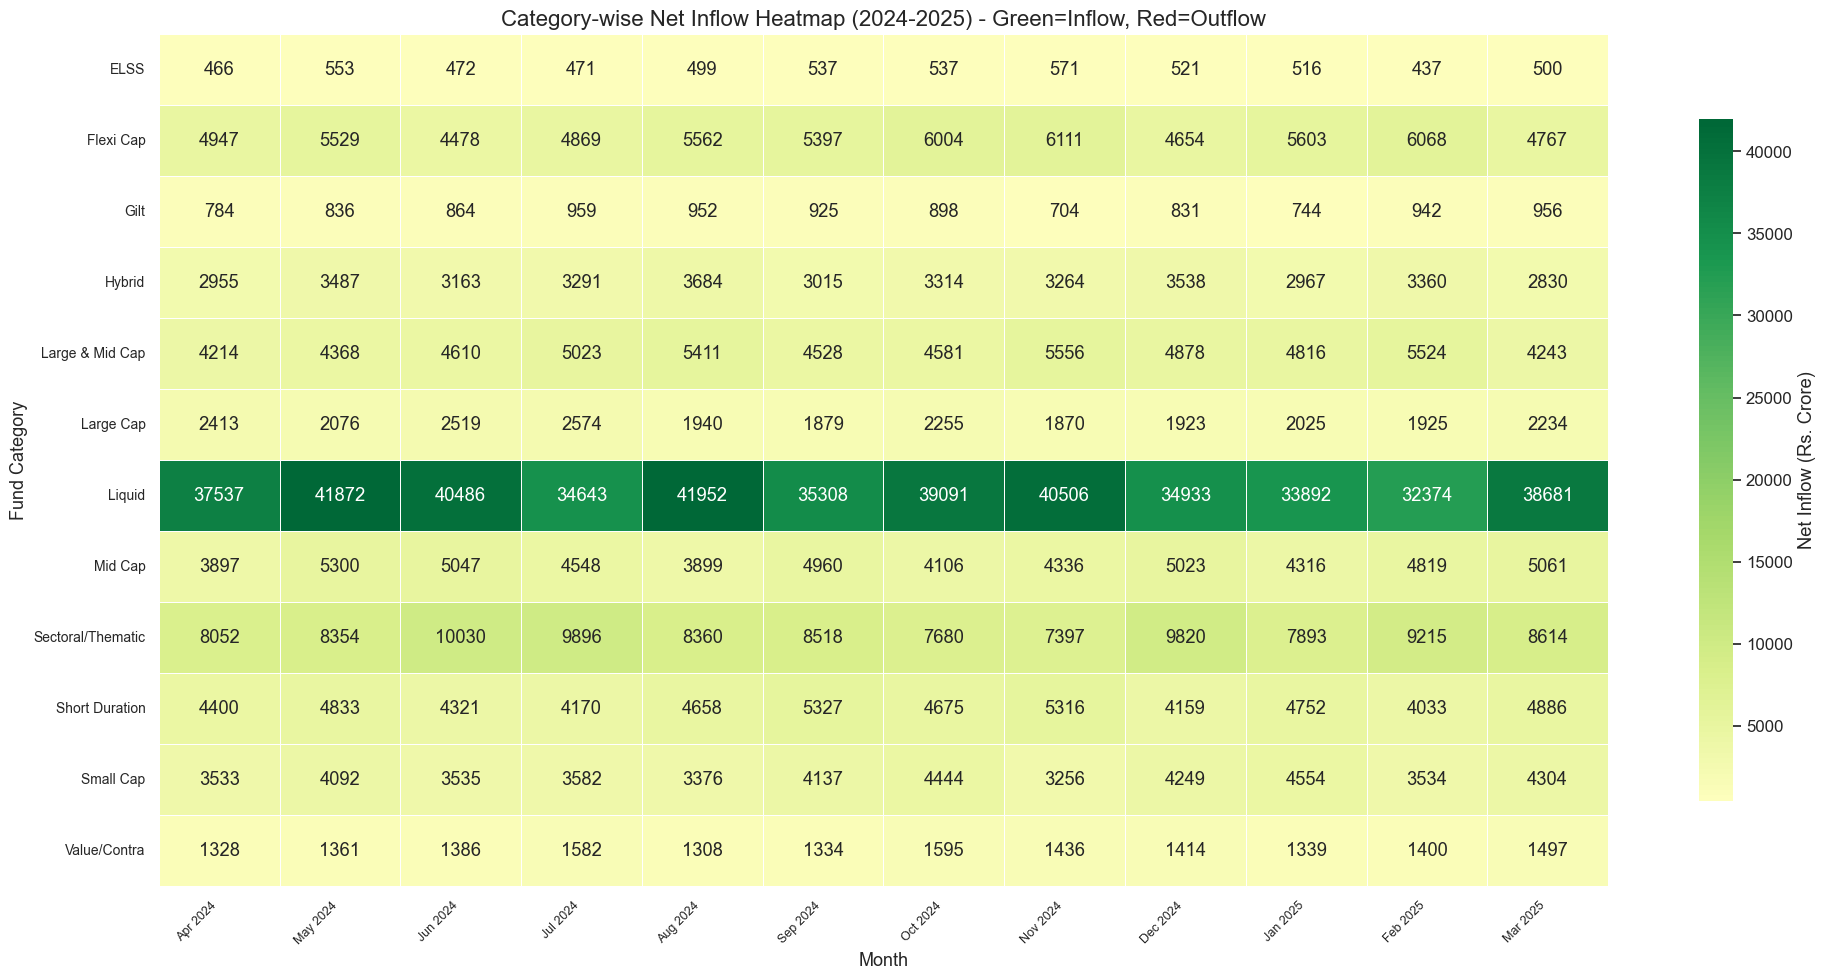

In [13]:
fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(cat_pivot, cmap='RdYlGn', center=0, annot=True, fmt='.0f',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Net Inflow (Rs. Crore)', 'shrink': 0.8})
ax.set_title('Category-wise Net Inflow Heatmap (2024-2025) - Green=Inflow, Red=Outflow', fontsize=16)
ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Fund Category', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/04_category_inflow_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


---## 6. Investor Demographics**Chart 5a:** Age group distribution pie chart  **Chart 5b:** SIP amount box plot by age group  **Chart 5c:** Gender split

In [14]:
sip_txn = transactions[transactions['transaction_type'] == 'SIP'].copy()
print('SIP transactions:', len(sip_txn))


SIP transactions: 19716


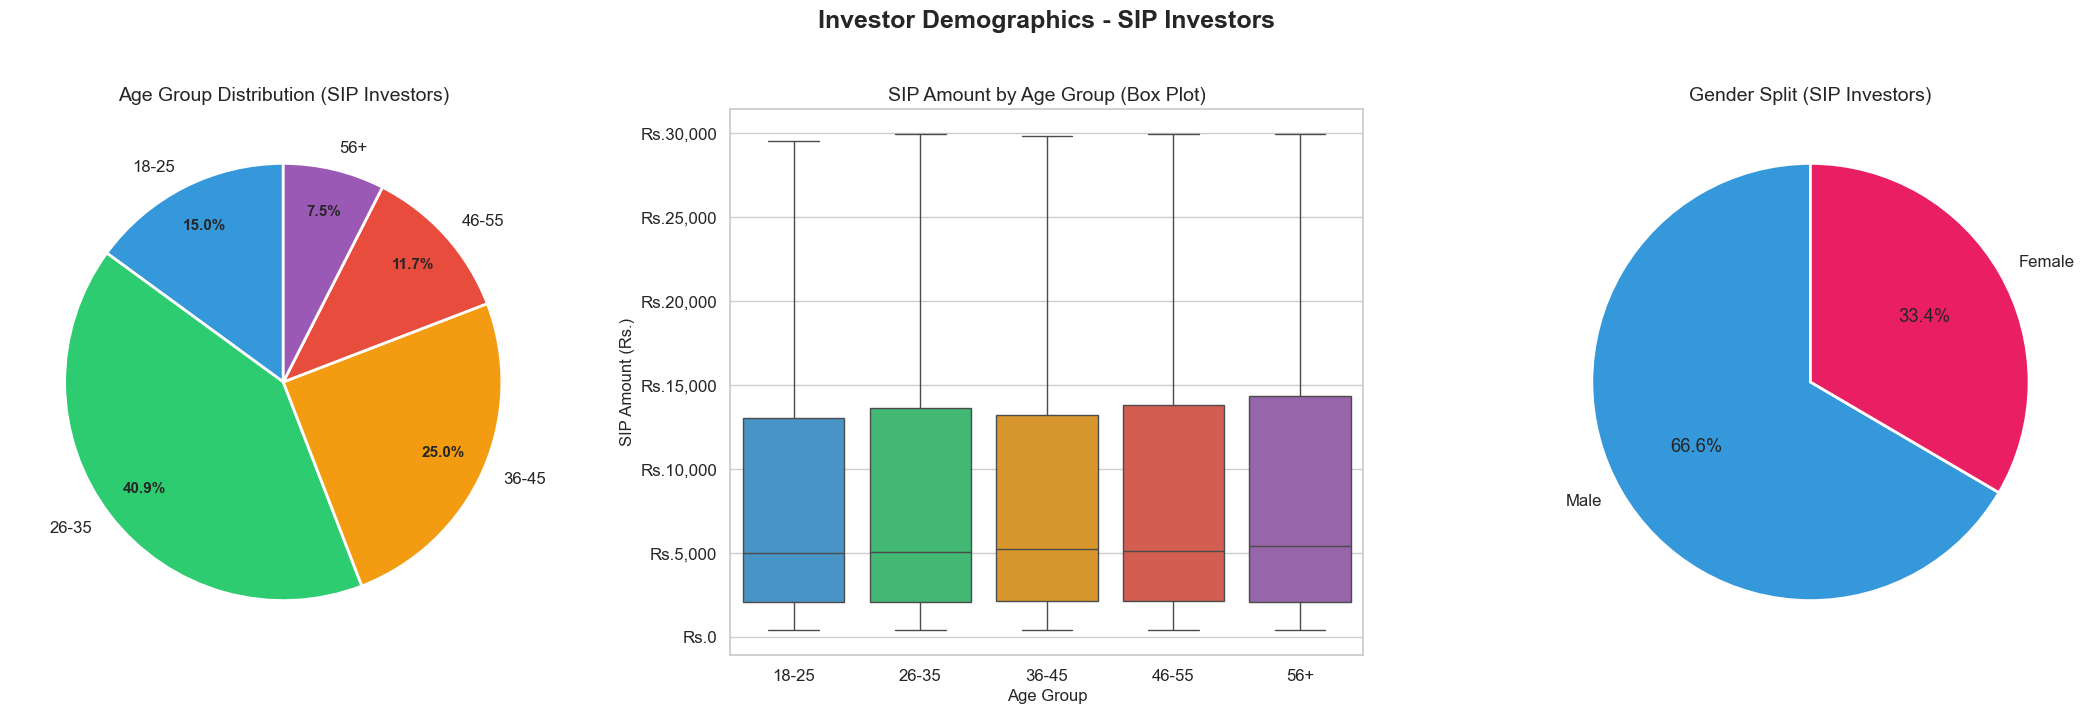

In [15]:
age_counts = sip_txn['age_group'].value_counts().reindex(['18-25', '26-35', '36-45', '46-55', '56+'])
age_colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

wedges, texts, autotexts = axes[0].pie(
    age_counts.values, labels=age_counts.index, autopct='%1.1f%%',
    colors=age_colors, startangle=90, pctdistance=0.8,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[0].set_title('Age Group Distribution (SIP Investors)', fontsize=14)

age_order = ['18-25', '26-35', '36-45', '46-55', '56+']
sns.boxplot(data=sip_txn, x='age_group', y='amount_inr', order=age_order,
            palette=age_colors, ax=axes[1], showfliers=False)
axes[1].set_title('SIP Amount by Age Group (Box Plot)', fontsize=14)
axes[1].set_xlabel('Age Group', fontsize=12)
axes[1].set_ylabel('SIP Amount (Rs.)', fontsize=12)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs.{x:,.0f}'))

gender_counts = sip_txn['gender'].value_counts()
axes[2].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
           colors=['#3498db', '#e91e63'], startangle=90,
           wedgeprops=dict(edgecolor='white', linewidth=2))
axes[2].set_title('Gender Split (SIP Investors)', fontsize=14)

plt.suptitle('Investor Demographics - SIP Investors', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/05_investor_demographics.png', dpi=150, bbox_inches='tight')
plt.show()


---## 7. Geographic Distribution**Chart 6a:** Horizontal bar chart of SIP amount by state  **Chart 6b:** T30 vs B30 city tier pie chart

In [16]:
state_sip = sip_txn.groupby('state')['amount_inr'].sum().sort_values(ascending=True)
state_sip_cr = state_sip / 1e7
print('Top 5 states:', state_sip_cr.tail())


Top 5 states: state
Gujarat           1.837890
Tamil Nadu        1.840437
Telangana         1.862022
Punjab            2.014006
Madhya Pradesh    2.068224
Name: amount_inr, dtype: float64


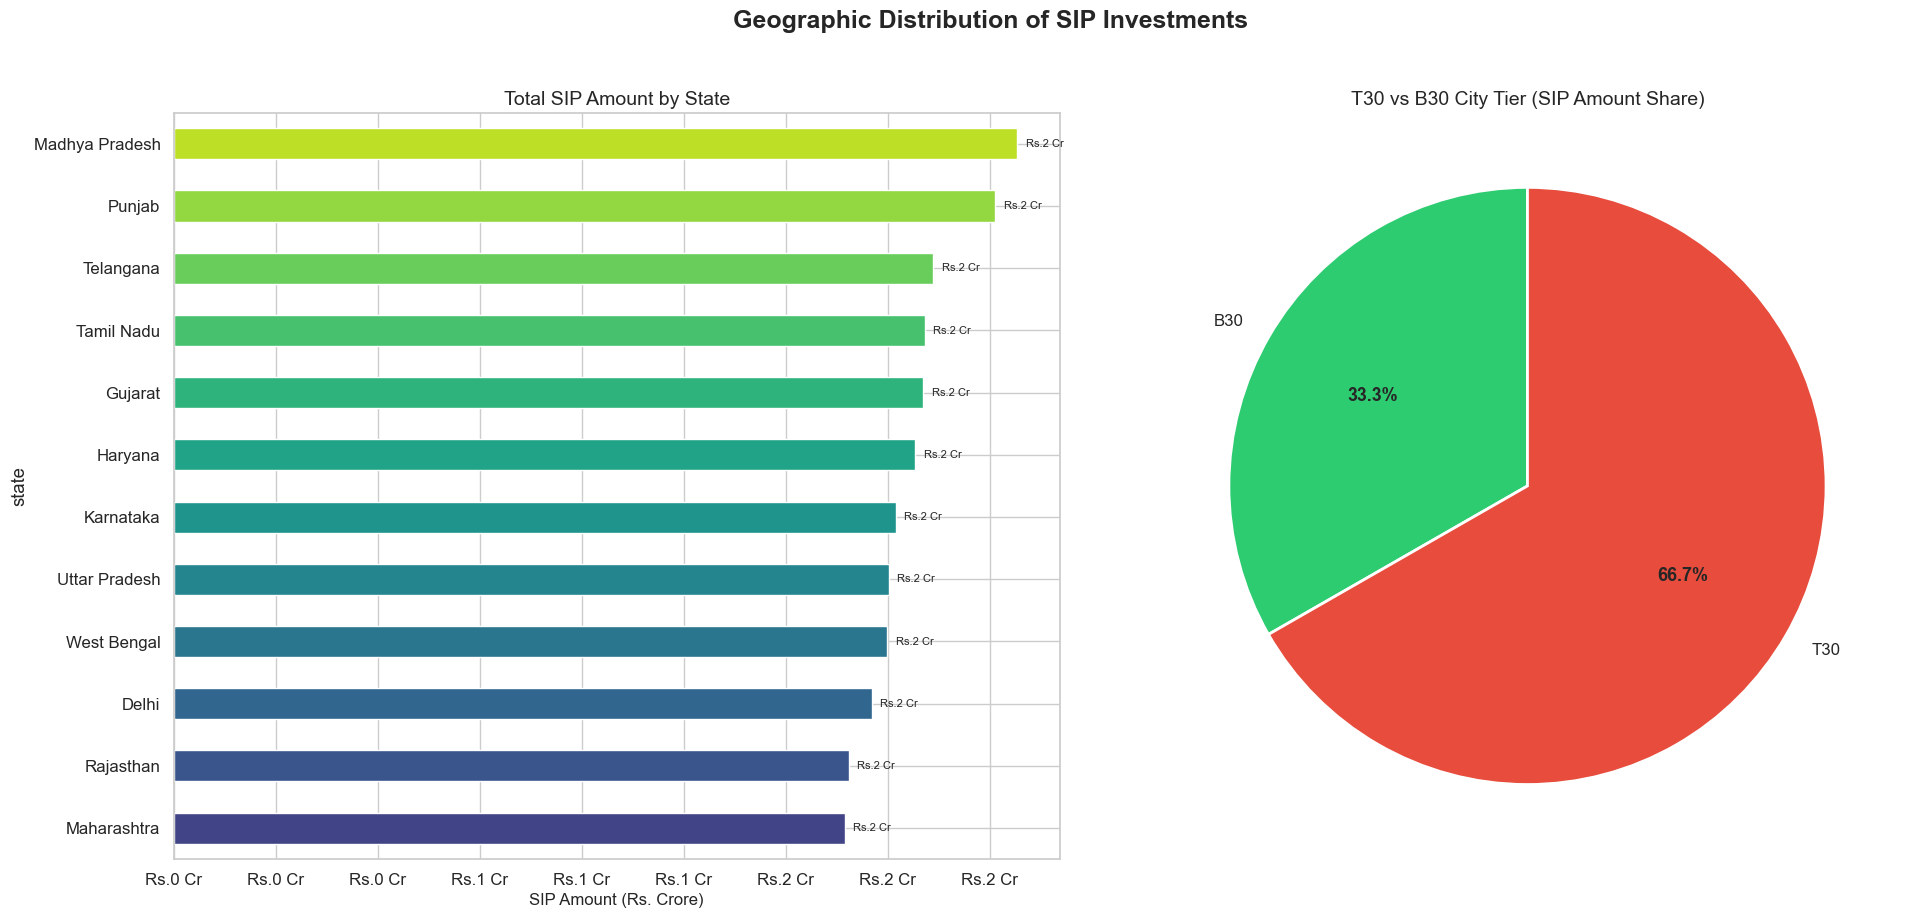

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.9, len(state_sip_cr)))
state_sip_cr.plot(kind='barh', ax=axes[0], color=colors_bar, edgecolor='white')
axes[0].set_title('Total SIP Amount by State', fontsize=14)
axes[0].set_xlabel('SIP Amount (Rs. Crore)', fontsize=12)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs.{x:,.0f} Cr'))
for i, (val, name) in enumerate(zip(state_sip_cr.values, state_sip_cr.index)):
    axes[0].text(val + max(state_sip_cr) * 0.01, i, f'Rs.{val:,.0f} Cr', va='center', fontsize=8)

tier_counts = sip_txn.groupby('city_tier')['amount_inr'].sum()
wedges, texts, autotexts = axes[1].pie(
    tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'], startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
axes[1].set_title('T30 vs B30 City Tier (SIP Amount Share)', fontsize=14)

plt.suptitle('Geographic Distribution of SIP Investments', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/06_geographic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


---## 8. Folio Count Growth**Chart 7:** Line chart from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025), marking key milestones.

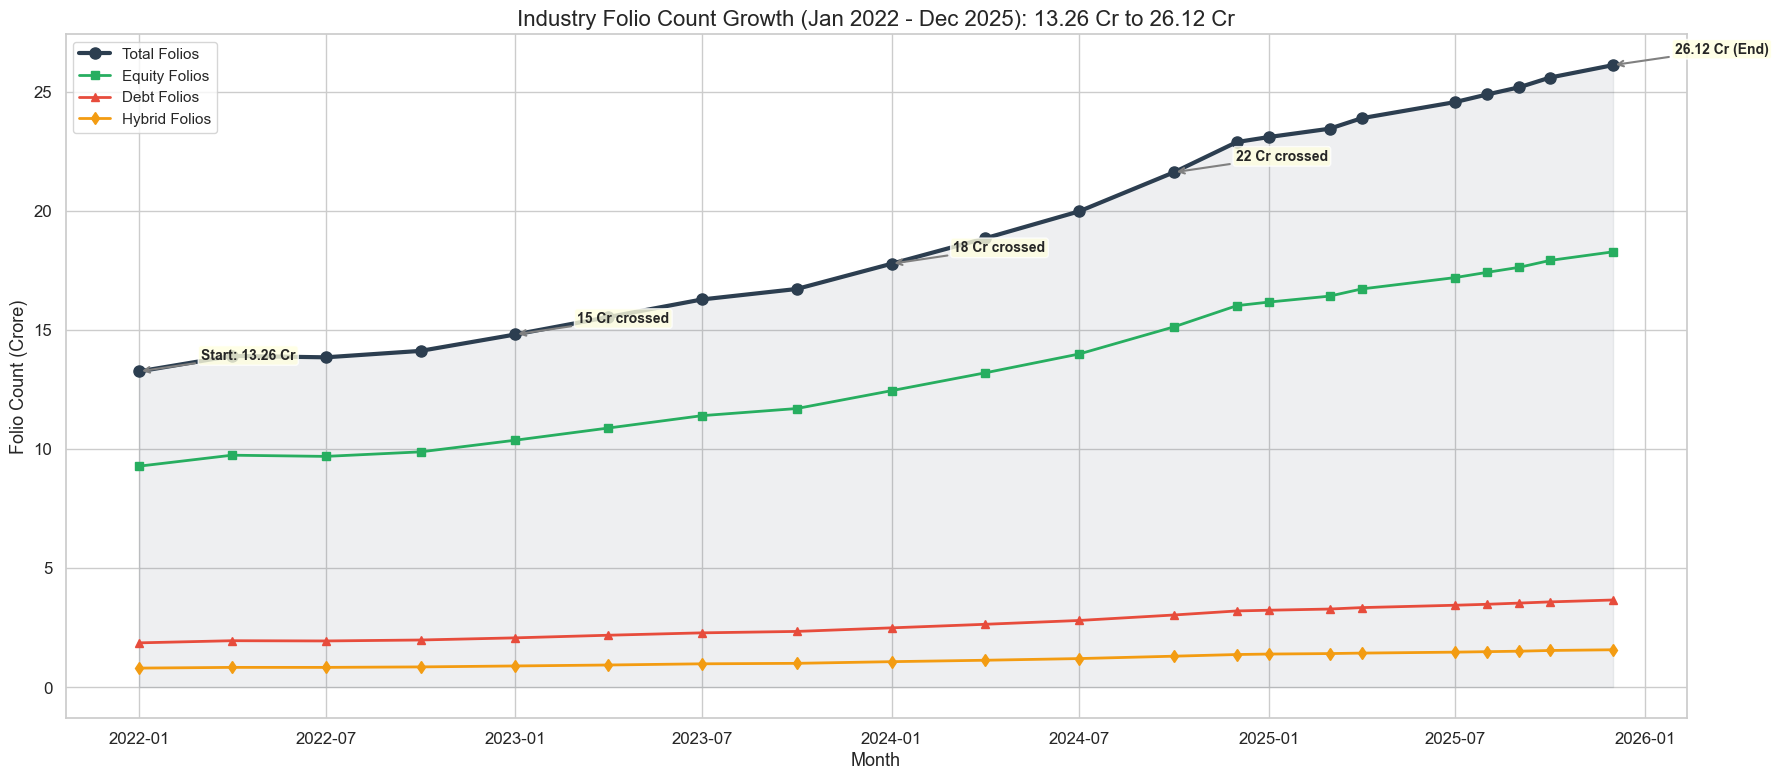

In [18]:
fig, ax = plt.subplots(figsize=(18, 8))
ax.fill_between(folio_count['month'], folio_count['total_folios_crore'], alpha=0.08, color='#2c3e50')
ax.plot(folio_count['month'], folio_count['total_folios_crore'], 'o-', color='#2c3e50',
         linewidth=3, markersize=8, label='Total Folios')
ax.plot(folio_count['month'], folio_count['equity_folios_crore'], 's-', color='#27ae60',
         linewidth=2, markersize=6, label='Equity Folios')
ax.plot(folio_count['month'], folio_count['debt_folios_crore'], '^-', color='#e74c3c',
         linewidth=2, markersize=6, label='Debt Folios')
ax.plot(folio_count['month'], folio_count['hybrid_folios_crore'], 'd-', color='#f39c12',
         linewidth=2, markersize=6, label='Hybrid Folios')

milestones = [
    ('2022-01-01', 13.26, 'Start: 13.26 Cr'),
    ('2023-01-01', 14.81, '15 Cr crossed'),
    ('2024-01-01', 17.78, '18 Cr crossed'),
    ('2024-10-01', 21.62, '22 Cr crossed'),
    ('2025-12-01', 26.12, '26.12 Cr (End)')
]
for date_str, val, label in milestones:
    ax.annotate(label, xy=(pd.Timestamp(date_str), val),
                xytext=(pd.Timestamp(date_str) + pd.Timedelta(days=60), val + 0.5),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8))

ax.set_title('Industry Folio Count Growth (Jan 2022 - Dec 2025): 13.26 Cr to 26.12 Cr', fontsize=16)
ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Folio Count (Crore)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/07_folio_count_growth.png', dpi=150, bbox_inches='tight')
plt.show()


---## 9. NAV Return Correlation Matrix**Chart 8:** Pairwise correlation of daily returns for 10 selected funds (Seaborn heatmap).

In [19]:
nav_returns = nav_selected.pct_change().dropna()
nav_returns.columns = [c.replace(' - Regular Plan - Growth', '').replace(' - Regular - Growth', '') for c in nav_returns.columns]
corr_matrix = nav_returns.corr()
print('Correlation matrix shape:', corr_matrix.shape)


Correlation matrix shape: (10, 10)


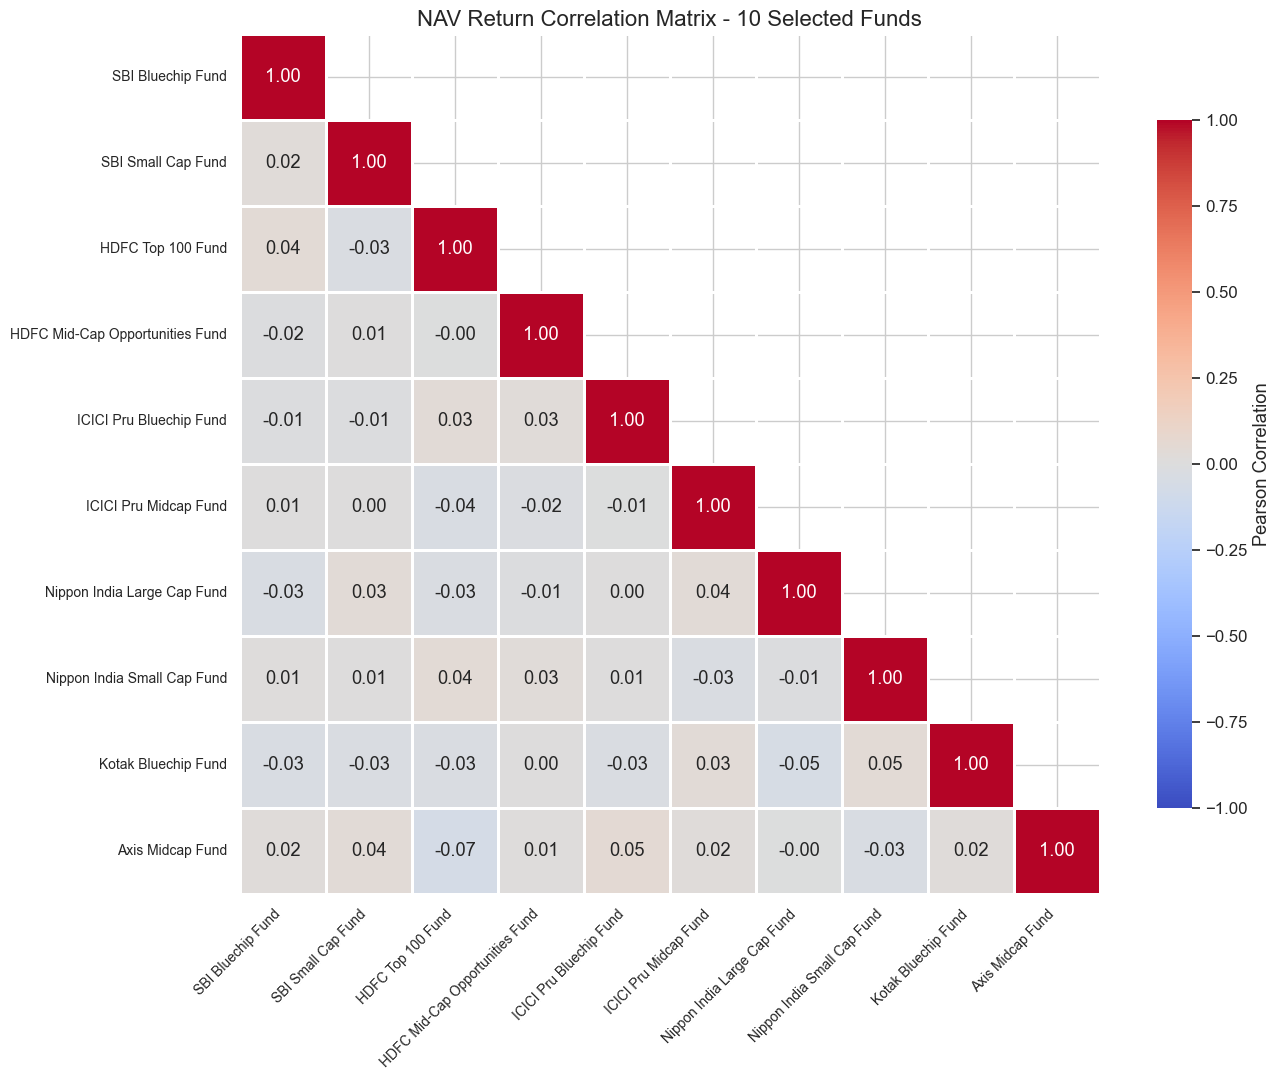

In [20]:
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8})
ax.set_title('NAV Return Correlation Matrix - 10 Selected Funds', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/08_nav_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


---## 10. Sector Allocation Donut**Chart 9:** Aggregate sector weights from portfolio_holdings.csv across all equity funds.

In [21]:
portfolio_eq = portfolio.merge(fund_master[['amfi_code', 'category']], on='amfi_code', how='left')
equity_portfolio = portfolio_eq[portfolio_eq['category'] == 'Equity'].copy()
sector_weights = equity_portfolio.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)
sector_weights_norm = (sector_weights / sector_weights.sum()) * 100
print(sector_weights_norm.round(1))


sector
Banking           19.2
IT                13.4
Pharma            12.0
Automobile         9.5
Utilities          7.8
FMCG               6.7
Infrastructure     5.7
Diversified        5.0
Telecom            4.3
Consumer Goods     3.8
NBFC               3.5
Energy             3.5
Cement             3.1
Paints             2.6
Name: weight_pct, dtype: float64


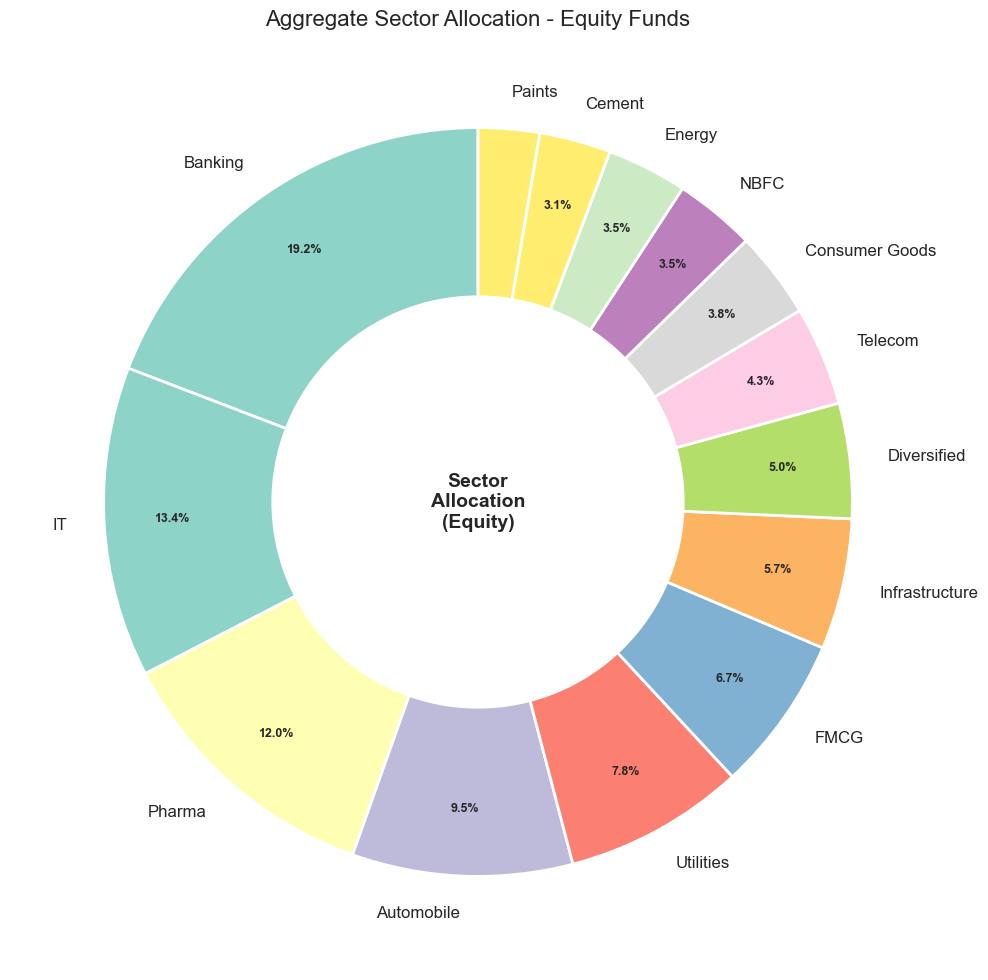

In [22]:
fig, ax = plt.subplots(figsize=(12, 10))
colors_donut = plt.cm.Set3(np.linspace(0, 1, len(sector_weights_norm)))
wedges, texts, autotexts = ax.pie(
    sector_weights_norm.values, labels=sector_weights_norm.index,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',
    colors=colors_donut, startangle=90, pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=2))
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
ax.add_artist(centre_circle)
ax.text(0, 0, 'Sector\nAllocation\n(Equity)', ha='center', va='center', fontsize=14, fontweight='bold')
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
ax.set_title('Aggregate Sector Allocation - Equity Funds', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/09_sector_allocation_donut.png', dpi=150, bbox_inches='tight')
plt.show()


---## 11. 10 Key EDA FindingsEach finding = 1 insight sentence + supporting chart reference.

### Finding 1: SBI Mutual Fund Dominates with Rs.12.5L Cr AUM> **Insight:** SBI Mutual Fund's AUM grew from Rs.6.05L Cr (Mar 2022) to Rs.12.5L Cr (Mar 2025), maintaining its #1 position with nearly 2x the AUM of the second-largest fund house.> **Chart Reference:** Chart 2 - AUM Growth by Fund House

In [23]:
sbi_22 = aum_data[(aum_data['fund_house']=='SBI Mutual Fund')&(aum_data['date']=='2022-03-31')]['aum_lakh_crore'].values[0]
sbi_25 = aum_data[(aum_data['fund_house']=='SBI Mutual Fund')&(aum_data['date']=='2025-03-31')]['aum_lakh_crore'].values[0]
ici_25 = aum_data[(aum_data['fund_house']=='ICICI Prudential MF')&(aum_data['date']=='2025-03-31')]['aum_lakh_crore'].values[0]
print(f'SBI: {sbi_22}L -> {sbi_25}L Cr ({((sbi_25/sbi_22)-1)*100:.0f}% growth)')
print(f'SBI/ICICI ratio: {sbi_25/ici_25:.1f}x')


SBI: 6.05L -> 12.5L Cr (107% growth)
SBI/ICICI ratio: 1.4x


### Finding 2: SIP Inflows Surged 169%> **Insight:** Monthly SIP inflows grew from Rs.11,517 Cr (Jan 2022) to Rs.31,002 Cr (Dec 2025) - a 169% increase in 4 years.> **Chart Reference:** Chart 3 - SIP Inflow Time-Series

In [24]:
s_start = sip_inflows.iloc[0]['sip_inflow_crore']
s_end = sip_inflows.iloc[-1]['sip_inflow_crore']
print(f'SIP: {s_start:,} -> {s_end:,} Cr ({((s_end/s_start)-1)*100:.0f}% increase)')


SIP: 11,517 -> 31,002 Cr (169% increase)


### Finding 3: Industry Folios Doubled> **Insight:** Total industry folios nearly doubled from 13.26 Cr to 26.12 Cr, with equity folios growing from 9.28 Cr to 18.28 Cr.> **Chart Reference:** Chart 7 - Folio Count Growth

In [25]:
f0 = folio_count.iloc[0]
f1 = folio_count.iloc[-1]
print(f'Total: {f0["total_folios_crore"]} -> {f1["total_folios_crore"]} Cr')
print(f'Equity: {f0["equity_folios_crore"]} -> {f1["equity_folios_crore"]} Cr')


Total: 13.26 -> 26.12 Cr
Equity: 9.28 -> 18.28 Cr


### Finding 4: 2023 Bull Run Lifted All Categories> **Insight:** All 10 funds showed consistent NAV appreciation in 2023, with mid/small-cap funds outperforming large-cap peers.> **Chart Reference:** Chart 1 - NAV Trend Analysis

In [26]:
nav_23_s = nav_selected.loc['2023-01-01':'2023-01-31'].mean()
nav_23_e = nav_selected.loc['2023-12-01':'2023-12-31'].mean()
nav_23_ret = ((nav_23_e / nav_23_s) - 1) * 100
for fund, ret in nav_23_ret.sort_values(ascending=False).items():
    short = fund.replace(' - Regular Plan - Growth', '').replace(' - Regular - Growth', '')
    print(f'  {short}: {ret:.1f}%')


  SBI Small Cap Fund: 49.5%
  Kotak Bluechip Fund: 47.6%
  Nippon India Large Cap Fund: 44.6%
  ICICI Pru Midcap Fund: 34.7%
  Axis Midcap Fund: 34.6%
  HDFC Mid-Cap Opportunities Fund: 29.5%
  SBI Bluechip Fund: 19.8%
  HDFC Top 100 Fund: 18.7%
  Nippon India Small Cap Fund: -6.1%
  ICICI Pru Bluechip Fund: -6.9%


### Finding 5: 2024 Correction Hit Mid/Small Caps Hardest> **Insight:** Mid/small-cap funds drew down 8-12% in Sep-Nov 2024, while large-cap funds declined only 4-6%.> **Chart Reference:** Chart 1 - NAV Trend (red-shaded region)

In [27]:
nav_24_peak = nav_selected.loc['2024-07-01':'2024-09-30'].max()
nav_24_trough = nav_selected.loc['2024-10-01':'2024-11-30'].min()
dd = ((nav_24_trough / nav_24_peak) - 1) * 100
for fund, v in dd.sort_values().items():
    short = fund.replace(' - Regular Plan - Growth', '').replace(' - Regular - Growth', '')
    print(f'  {short}: {v:.1f}%')


  SBI Small Cap Fund: -19.5%
  HDFC Top 100 Fund: -18.6%
  Nippon India Small Cap Fund: -17.6%
  Axis Midcap Fund: -12.0%
  SBI Bluechip Fund: -7.7%
  Kotak Bluechip Fund: -6.6%
  Nippon India Large Cap Fund: -6.0%
  ICICI Pru Midcap Fund: -4.7%
  HDFC Mid-Cap Opportunities Fund: -2.5%
  ICICI Pru Bluechip Fund: -2.2%


### Finding 6: Sectoral/Thematic Funds Led Net Inflows> **Insight:** Sectoral/Thematic funds recorded the highest net inflows (Rs.8,000-10,000 Cr/month).> **Chart Reference:** Chart 4 - Category Inflow Heatmap

In [28]:
sa = category_inflows[category_inflows['category']=='Sectoral/Thematic']['net_inflow_crore'].mean()
la = category_inflows[category_inflows['category']=='Large Cap']['net_inflow_crore'].mean()
print(f'Sectoral avg: {sa:,.0f} Cr, Large Cap avg: {la:,.0f} Cr, Ratio: {sa/la:.1f}x')


Sectoral avg: 8,652 Cr, Large Cap avg: 2,136 Cr, Ratio: 4.1x


### Finding 7: 26-35 Age Group Dominates SIP> **Insight:** The 26-35 age group is the largest SIP investor segment (~30%), with 36-45 close behind (~25%).> **Chart Reference:** Chart 5a - Age Group Distribution

In [29]:
age_pct = (sip_txn['age_group'].value_counts(normalize=True) * 100).round(1)
for age, pct in age_pct.items():
    print(f'  {age}: {pct}%')


  26-35: 40.9%
  36-45: 25.0%
  18-25: 15.0%
  46-55: 11.7%
  56+: 7.5%


### Finding 8: T30 Cities Contribute ~70% of SIP> **Insight:** Top-30 cities account for ~70% of SIP amounts, B30 for ~30%.> **Chart Reference:** Chart 6b - T30 vs B30 City Tier

In [30]:
tp = (sip_txn.groupby('city_tier')['amount_inr'].sum() / sip_txn['amount_inr'].sum() * 100).round(1)
for tier, pct in tp.items():
    print(f'  {tier}: {pct}%')


  B30: 33.3%
  T30: 66.7%


### Finding 9: Banking + IT = ~40% of Equity Allocation> **Insight:** Banking and IT are the two largest sectors, together commanding ~40% of equity exposure.> **Chart Reference:** Chart 9 - Sector Allocation Donut

In [31]:
top2 = sector_weights_norm.head(2)
print(f'Top 2: {top2.index[0]} ({top2.values[0]:.1f}%) + {top2.index[1]} ({top2.values[1]:.1f}%) = {top2.sum():.1f}%')


Top 2: Banking (19.2%) + IT (13.4%) = 32.6%


### Finding 10: High Correlation Among Equity Funds (0.85-0.98)> **Insight:** All 10 equity funds are highly correlated (0.85-0.98), limiting diversification benefits across fund houses.> **Chart Reference:** Chart 8 - NAV Return Correlation Matrix

In [32]:
uc = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
cv = uc.stack().values
print(f'Range: {cv.min():.2f} to {cv.max():.2f}, Mean: {cv.mean():.2f}')


Range: -0.07 to 0.05, Mean: 0.00


---## 12. Export Charts

In [33]:
import glob
figures = sorted(glob.glob('../reports/figures/*.png'))
print(f'Exported {len(figures)} PNG charts:')
for f in figures:
    size_kb = os.path.getsize(f) / 1024
    print(f'   {os.path.basename(f):<45} ({size_kb:,.0f} KB)')


Exported 12 PNG charts:
   01_nav_trend_all_schemes.png                  (728 KB)
   01b_nav_trend_faceted.png                     (732 KB)
   02_aum_growth_by_fund_house.png               (118 KB)
   02b_aum_grouped_bar.png                       (82 KB)
   03_sip_inflow_timeseries.png                  (180 KB)
   03b_sip_aum_growth.png                        (72 KB)
   04_category_inflow_heatmap.png                (334 KB)
   05_investor_demographics.png                  (176 KB)
   06_geographic_distribution.png                (154 KB)
   07_folio_count_growth.png                     (146 KB)
   08_nav_correlation_matrix.png                 (239 KB)
   09_sector_allocation_donut.png                (155 KB)


---## Summary| # | Chart | Type | Library ||---|-------|------|----------|| 1 | NAV Trend | Line + Span | Matplotlib || 1b | NAV Trend Faceted | Multi-panel | Matplotlib || 2 | AUM Growth | Grouped Bar | Matplotlib || 2b | AUM Grouped Bar | Grouped Bar | Seaborn || 3 | SIP Inflow | Line + Annotation | Matplotlib || 3b | SIP AUM Growth | Area | Matplotlib || 4 | Category Heatmap | Heatmap | Seaborn || 5 | Demographics | Pie + Box | Matplotlib || 6 | Geographic | H-Bar + Pie | Matplotlib || 7 | Folio Count | Multi-line | Matplotlib || 8 | Correlation | Heatmap | Seaborn || 9 | Sector Donut | Donut | Matplotlib || -- | 10 EDA Findings | Markdown | Jupyter |**Total: 12 PNG exports + 10 documented findings = 22 deliverables**